# STATISTIC ANALYSIS OF EXOPLANET TERMINATOR AND TRANSIT PHASES ASYMMETRY

    
This Jupyter notebook implements and analyses the project defined in the files "Projekat_za_Nacionalnu Konferenciju_Astrostat" and "TRANSIT_WASP17B".

The notebook automatically generates the spectral input required for the analysis for different levels of terminator asymmetry and for the three transit phases: ingress, mid-transit and egress. This automation reduces the possibility of human error when preparing and managing the input files.

The generated PSG spectra are saved as `.txt` files, while the resulting statistical metrics are stored in `.csv` files for further analysis.

The analysis starts from the ultra-asymmetric configuration, representing the most extreme asymmetry considered in this study. The investigated parameter variations include atmospheric temperature, cloud fraction and atmospheric abundance.

## Statistical analysis and hypothesis testing

The statistical analysis quantifies the detectability of ingress-egress spectral differences as a function of the imposed terminator asymmetry α.

The null test is defined by α = 0, where the ingress and egress configurations are identical. This case serves as a control for the analysis pipeline and represents the expected result in the absence of imposed terminator asymmetry.

The null hypothesis is H₀: F_ingress(λ) = F_egress(λ). The alternative hypothesis is that the ingress and egress spectra differ at one or more wavelengths.

The asymmetry parameter α is varied from 0 to 1. Atmospheric temperature, cloud fraction and atmospheric abundance are investigated independently, with one physical parameter varied at a time while the remaining configuration is kept fixed. For every parameter, the same set of α values is analysed and the resulting ingress and egress spectra are compared. The mid-transit spectrum is retained as a reference phase but is not used in the ingress-egress difference.

For each wavelength bin, the spectral difference is ΔF = F_ingress − F_egress. The corresponding uncertainty is obtained directly from the PSG uncertainties: σ_comb = √(σ_ingress² + σ_egress²).

The main statistical measures are χ², reduced χ², RMS spectral difference, mean detection significance, maximum detection significance and Gaussian log-likelihood. The chi-square statistic is calculated from the standardized spectral differences, χ² = Σ(ΔF / σ_comb)², with χ²_red = χ² / dof. The RMS difference measures the absolute spectral separation, while the detection significance is defined as σ_det = |ΔF| / σ_comb.

For each selected wavelength region, the mean σ_det is calculated using the absolute standardized difference. The absolute value prevents positive and negative spectral deviations from cancelling each other within a region. The maximum σ_det is also recorded to identify the wavelength with the strongest local difference.

The Gaussian log-likelihood is calculated using the same spectral differences and PSG uncertainties. All uncertainties are taken directly from the PSG-generated spectra, without additional empirical rescaling.

The regional results are interpreted together with the number of wavelength bins, spectral resolution and the adopted PSG noise model, since these factors can influence the apparent detectability of terminator asymmetry.

In [ ]:
"""Necessary imports for PSG asymmetry analysis."""
import os
import re
try:
    import resource
except ImportError:
    resource = None
import time
from IPython.display import display
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
# Elevate Linux/Binder file descriptor limits to avoid "too many open files" errors
if resource is not None:
    try:
        soft_lim, hard_lim = resource.getrlimit(resource.RLIMIT_NOFILE)
        if soft_lim < hard_lim:
            resource.setrlimit(resource.RLIMIT_NOFILE, (hard_lim, hard_lim))
        print(f"File descriptor limit updated: {soft_lim} -> {hard_lim}")
    except OSError as resource_err:
        print(f"File limit check failed: {resource_err}")

# Automatised generation of PSG spectra

This cell automates:
- Varying the asymmetry level;
- Sending `.cfg` files to the NASA PSG system;
- Downloading `psg_rad.txt`;
- Renaming files according to:
  - asymmetry level;
  - transit phase (`ingress`, `mid`, `egress`);
- Placing the generated files in the appropriate folders.

After executing this cell:
- the rest of the notebook works without modification;
- the analysis, graphs and tables are generated automatically.

In [19]:
PSG_URL = "https://psg.gsfc.nasa.gov/api.php"
OUTPUT_ROOT_DIR = "./output_results"
CFG_TEMPLATES = {"ingress": "Asym_1.0/wasp17b_transit_ingress_ultra_hazy_cold.cfg",
    "mid": "Asym_1.0/wasp17b_transit_mid_ultra_reference.cfg",
    "egress": "Asym_1.0/wasp17b_transit_egress_ultra_clear_hot.cfg",}
ASYM_PARAMS = ["TEMPERATURE", "CLOUDFRACTION", "AABUN"]
GEOMETRY_TAGS = ["<GEOMETRY-OFFSET-EW>", "<GEOMETRY-OFFSET-NS>"]
def get_cfg_val(cfg_content, tag_name):
    """Extract float value for specified tag from PSG configuration string."""
    res = re.search(rf"<{tag_name}>([-+0-9.eE]+)", cfg_content)
    return float(res.group(1)) if res else None
def set_cfg_val(cfg_content, tag_name, val_num):
    """Replace value for specified tag in PSG configuration string."""
    return re.sub(rf"<{tag_name}>[-+0-9.eE]+", f"<{tag_name}>{val_num}", cfg_content)
def apply_geometry(target_cfg, geo_source_cfg):
    """Copies physical observational geometry tags from source template."""
    out_cfg = target_cfg
    for g_tag in GEOMETRY_TAGS:
        t_name = g_tag.strip("<>")
        ref_val = get_cfg_val(geo_source_cfg, t_name)
        if ref_val is not None:
            out_cfg = set_cfg_val(out_cfg, t_name, ref_val)
    return out_cfg
def interpolate_temperature_layers(mid_cfg, ext_cfg, alpha_val):
    """Interpolate layer temperatures between mid-transit and phase CFG."""
    out_cfg = mid_cfg
    for layer_idx in range(1, 51):
        pattern = rf"(<ATMOSPHERE-LAYER-{layer_idx}>)([^\n]+)"
        mid_match = re.search(pattern, mid_cfg)
        ext_match = re.search(pattern, ext_cfg)
        if not mid_match or not ext_match:
            continue
        mid_values = mid_match.group(2).split(",")
        ext_values = ext_match.group(2).split(",")
        mid_values[1] = str(float(mid_values[1]) + alpha_val *
                             (float(ext_values[1]) - float(mid_values[1])))
        replacement = mid_match.group(1) + ",".join(mid_values)
        out_cfg = re.sub(pattern, replacement, out_cfg, count=1)
    return out_cfg
def interpolate_atmosphere(ext_phase_cfg, mid_cfg, alpha_val, target_param):
    """Isolates target_param while keeping other parameters at mid_cfg values.
    Phase-specific geometry is inherited from ext_phase_cfg.
    """
    out_cfg = apply_geometry(mid_cfg, ext_phase_cfg)
    for p_name in ["TEMPERATURE", "CLOUDFRACTION", "AABUN", "ASIZE"]:
        if p_name != target_param:
            m_val = get_cfg_val(mid_cfg, f"ATMOSPHERE-{p_name}")
            if m_val is not None:
                out_cfg = set_cfg_val(out_cfg, f"ATMOSPHERE-{p_name}", m_val)
            l_tag = f"ATMOSPHERE-LAYERS-{p_name}"
            m_layers_match = re.search(rf"<{l_tag}>([0-9.,\-+eE\s]+)", mid_cfg)
            if m_layers_match:
                out_cfg = re.sub(rf"<{l_tag}>[0-9.,\-+eE\s]+",
                    f"<{l_tag}>{m_layers_match.group(1)}", out_cfg,)
    t_tag = f"ATMOSPHERE-{target_param}"
    l_tag = f"ATMOSPHERE-LAYERS-{target_param}"
    m_val = get_cfg_val(mid_cfg, t_tag)
    e_val = get_cfg_val(ext_phase_cfg, t_tag)
    if m_val is not None and e_val is not None:
        out_cfg = set_cfg_val(out_cfg, t_tag, m_val + alpha_val * (e_val - m_val))
    m_layers_match = re.search(rf"<{l_tag}>([0-9.,\-+eE\s]+)", mid_cfg)
    e_layers_match = re.search(rf"<{l_tag}>([0-9.,\-+eE\s]+)", ext_phase_cfg)
    if m_layers_match and e_layers_match:
        m_arr = np.array([float(x) for x in m_layers_match.group(1).replace(" ", "").split(",")])
        e_arr = np.array([float(x) for x in e_layers_match.group(1).replace(" ", "").split(",")])
        arr_str = ",".join([f"{x:.6g}" for x in (m_arr + alpha_val * (e_arr - m_arr))])
        out_cfg = re.sub(rf"<{l_tag}>[0-9.,\-+eE\s]+", f"<{l_tag}>{arr_str}", out_cfg)
    if target_param == "TEMPERATURE":
        out_cfg = interpolate_temperature_layers(mid_cfg,
                                                  ext_phase_cfg, alpha_val)
    return out_cfg
def fetch_psg_spectrum(cfg_text_input, txt_output_path):
    """Generate and save a PSG spectrum through the API."""
    print(f"\n[{os.path.basename(txt_output_path)}]")
    api_success = False
    for attempt in range(3):
        try:
            print(f"Sending configuration to PSG API (attempt {attempt + 1}/3)...")
            resp = requests.post(PSG_URL, data=cfg_text_input.encode("utf-8"),
                headers={"User-Agent": "Mozilla/5.0", "Content-Type": "text/plain"},
                timeout=300,)
            valid_header = "# Wave/freq" in resp.text or "#Wave/freq" in resp.text
            if resp.status_code == 200 and valid_header:
                with open(txt_output_path, "w", encoding="utf-8") as out_txt:
                    out_txt.write(resp.text)
                api_success = True
                break
            print(f"PSG API returned HTTP {resp.status_code} or missing wavelength header.")
            print(f"Response preview:\n{resp.text[:500]}")
        except requests.RequestException as req_err:
            print(f"PSG API attempt {attempt + 1}/3 failed: {req_err}")
        if attempt < 2:
            time.sleep(2)
    if not api_success:
        raise RuntimeError("PSG API did not return a valid spectrum.")
    print("Spectrum saved via API.")
def load_cfg_templates():
    """Load the three base PSG configuration templates."""
    with open(CFG_TEMPLATES["ingress"], "r", encoding="utf-8") as file_ing:
        cfg_ing_base = file_ing.read()
    with open(CFG_TEMPLATES["mid"], "r", encoding="utf-8") as file_mid:
        cfg_mid = file_mid.read()
    with open(CFG_TEMPLATES["egress"], "r", encoding="utf-8") as file_eg:
        cfg_eg_base = file_eg.read()
    return cfg_ing_base, cfg_mid, cfg_eg_base
def run_asymmetry_pipeline():
    """Executes full atmospheric interpolation and spectrum generation pipeline."""
    cfg_ing_base, cfg_mid, cfg_eg_base = load_cfg_templates()
    print("\n=== TEMPLATE GEOMETRY CHECK ===")
    print("Ingress EW:", get_cfg_val(cfg_ing_base, "GEOMETRY-OFFSET-EW"))
    print("Mid EW    :", get_cfg_val(cfg_mid, "GEOMETRY-OFFSET-EW"))
    print("Egress EW :", get_cfg_val(cfg_eg_base, "GEOMETRY-OFFSET-EW"))
    print("Ingress NS:", get_cfg_val(cfg_ing_base, "GEOMETRY-OFFSET-NS"))
    print("Mid NS    :", get_cfg_val(cfg_mid, "GEOMETRY-OFFSET-NS"))
    print("Egress NS :", get_cfg_val(cfg_eg_base, "GEOMETRY-OFFSET-NS"))
    print("===============================\n")
    total_runs = 0
    α_levels = [round(a, 1) for a in np.linspace(0.0, 1.0, 11)]
    for p_mode in ASYM_PARAMS:
        print(f"\n--- RUNNING ISOLATION SWEEP: Param_{p_mode} ---")
        for α in α_levels:
            current_asym_dir = os.path.join(OUTPUT_ROOT_DIR, f"Param_{p_mode}_Asym_{α:.1f}")
            os.makedirs(current_asym_dir, exist_ok=True)
            ing_cfg = interpolate_atmosphere(cfg_ing_base, cfg_mid, α, p_mode)
            eg_cfg = interpolate_atmosphere(cfg_eg_base, cfg_mid, α, p_mode)
            if α == 0.0 and p_mode == "TEMPERATURE":
                print("Ingress EW:", get_cfg_val(ing_cfg, "GEOMETRY-OFFSET-EW"))
                print("Mid EW    :", get_cfg_val(cfg_mid, "GEOMETRY-OFFSET-EW"))
                print("Egress EW :", get_cfg_val(eg_cfg, "GEOMETRY-OFFSET-EW"))
                print("Ingress NS:", get_cfg_val(ing_cfg, "GEOMETRY-OFFSET-NS"))
                print("Mid NS    :", get_cfg_val(cfg_mid, "GEOMETRY-OFFSET-NS"))
                print("Egress NS :", get_cfg_val(eg_cfg, "GEOMETRY-OFFSET-NS"))
                print("===========================\n")
            scenarios = {"ingress": ing_cfg, "mid": cfg_mid, "egress": eg_cfg}
            for phase_key, scenario_cfg in scenarios.items():
                current_cfg_path = os.path.join(current_asym_dir, f"{phase_key}.cfg")
                current_txt_path = os.path.join(current_asym_dir, f"{phase_key}.txt")
                with open(current_cfg_path, "w", encoding="utf-8") as out_cfg_file:
                    out_cfg_file.write(scenario_cfg)
                fetch_psg_spectrum(scenario_cfg, current_txt_path,)
                total_runs += 1
            print(f" Done α = {α:.1f} -> Generated spectra for {p_mode}")
    print(f"\nPIPELINE COMPLETE. Total generated phase runs: {total_runs}")
#run_asymmetry_pipeline()

In [ ]:
EXPECTED_GEOMETRY = {"ingress": (-0.92, 0.21),
    "mid": (0.0, 0.21), "egress": (0.92, 0.21),}
diagnostic_rows = []
valid_dirs = sorted([d for d in os.listdir(OUTPUT_ROOT_DIR) if d.startswith("Param_")
        and os.path.isdir(os.path.join(OUTPUT_ROOT_DIR, d))])
for asym_dir_item in valid_dirs:
    asym_path = os.path.join(OUTPUT_ROOT_DIR, asym_dir_item)
    for phase, (expected_ew, expected_ns) in EXPECTED_GEOMETRY.items():
        check_cfg_path = os.path.join(asym_path, f"{phase}.cfg")
        check_txt_path = os.path.join(asym_path, f"{phase}.txt")
        cfg_ok = os.path.isfile(check_cfg_path)
        txt_ok = (os.path.isfile(check_txt_path)
            and os.path.getsize(check_txt_path) > 0)
        actual_ew = actual_ns = None
        geometry_ok = False
        if cfg_ok:
            with open(check_cfg_path, "r", encoding="utf-8") as diag_file:
                diag_cfg_text = diag_file.read()
            actual_ew = get_cfg_val(diag_cfg_text, "GEOMETRY-OFFSET-EW")
            actual_ns = get_cfg_val(diag_cfg_text, "GEOMETRY-OFFSET-NS")
            geometry_ok = (actual_ew is not None and actual_ns is not None
                and np.isclose(actual_ew, expected_ew) and np.isclose(actual_ns, expected_ns))
        diagnostic_rows.append({"Param/α": asym_dir_item.replace("Param_",
                "").replace("_Asym_"," α="), "Phase": phase, "CFG": cfg_ok, "TXT": txt_ok,
                "EW": actual_ew, "NS": actual_ns, "Geometry": geometry_ok,})
diagnostic_df = pd.DataFrame(diagnostic_rows)
problems = diagnostic_df[(~diagnostic_df["CFG"]) | (~diagnostic_df["TXT"])
    | (~diagnostic_df["Geometry"])]
if problems.empty:
    print(f"Diagnostic OK: {len(diagnostic_df)} phase runs checked; "
        "all CFG/TXT files exist and all geometries match expected values.")
else:
    print(f"Diagnostic found {len(problems)} problem(s) out of {len(diagnostic_df)} checked runs.")
    display(problems)

Diagnostic OK: 99 phase runs checked; all CFG/TXT files exist and all geometries match expected values.


In [24]:
"""
Interactive Widget Analysis and Statistical Processing Engine.
"""
# Turn off automatic Matplotlib display to prevent duplication leaks in widgets
plt.ioff()
# Define spectral analysis wavelength regions [μm]
regions = [
    (0.80, 1.00),  # Rayleigh + optical continuum / H− slope
    (1.00, 1.16),  # Continuum baseline
    (1.16, 1.30),  # Weak H2O + continuum transition
    (1.30, 1.50),  # STRONG H2O band (main asymmetry signal)
    (1.50, 1.70),  # H2O wing / opacity plateau
    (1.70, 1.95),  # Second H2O band
    (1.95, 2.20),  # Deep IR tail (temperature + opacity interplay)
]
WORK_DIR = os.getcwd()
ANALYSIS_RESULTS = []
def load_phase_data(target_folder_path):
    """Load phase spectrum files and remove NaN values."""
    def load_one(phase_name):
        file_path = os.path.join(target_folder_path, f"{phase_name}.txt")
        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Expected file missing: {file_path}")
        raw_arr = np.loadtxt(file_path)
        array_data = np.array(raw_arr)
        return array_data[~np.isnan(array_data).any(axis=1)]
    return (load_one("ingress"), load_one("mid"), load_one("egress"))
def bin_spectrum(λ_arr, flux_arr, sigma_arr, nbins=30):
    """Bins spectrum using weighted averaging."""
    edges = np.linspace(λ_arr.min(), λ_arr.max(), nbins + 1)
    λ_bin = 0.5 * (edges[:-1] + edges[1:])
    f_bin = np.zeros(nbins)
    sigma_bin = np.zeros(nbins)
    for b_idx in range(nbins):
        mask_bin = (λ_arr >= edges[b_idx]) & (λ_arr < edges[b_idx + 1])
        if np.any(mask_bin):
            weights = 1 / sigma_arr[mask_bin] ** 2
            f_bin[b_idx] = np.sum(flux_arr[mask_bin] * weights) / np.sum(weights)
            sigma_bin[b_idx] = np.sqrt(1 / np.sum(weights))
        else:
            f_bin[b_idx] = np.nan
            sigma_bin[b_idx] = np.nan
    return λ_bin, f_bin, sigma_bin
def plot_transit_spectra(lambda_grid_in, f_ing_in, f_mid_in, f_egr_in, folder_label):
    """Visualizes spectra and phase differences safely within widgets."""
    plot_fig, axes_spec = plt.subplots(1, 2, figsize=(12, 4.5))
    ax_left = axes_spec[0]
    ax_left.plot(lambda_grid_in, f_ing_in, label="Ingress", alpha=0.85)
    ax_left.plot(lambda_grid_in, f_mid_in, label="Mid-transit", alpha=0.85)
    ax_left.plot(lambda_grid_in, f_egr_in, label="Egress", alpha=0.85)
    for r1_v, r2_v in regions:
        ax_left.axvline(r1_v, linestyle="--", color="red", alpha=0.3)
        ax_left.axvline(r2_v, linestyle="--", color="red", alpha=0.3)
    ax_left.set_xlabel(r"λ [μm]")
    ax_left.set_ylabel("Transit Depth / Flux Ratio")
    ax_left.set_title("Phase Transit Spectra")
    ax_left.legend(fontsize=8)
    ax_left.grid(True, linestyle=":", alpha=0.5)
    ax_right = axes_spec[1]
    ax_right.plot(lambda_grid_in, f_ing_in - f_mid_in, label="Ingress − Mid", alpha=0.85)
    ax_right.plot(lambda_grid_in, f_egr_in - f_mid_in, label="Egress − Mid",
                   alpha=0.85)
    ax_right.plot(lambda_grid_in, f_ing_in - f_egr_in, label="Ingress − Egress",
                   alpha=0.85)
    for r1_v, r2_v in regions:
        ax_right.axvline(r1_v, linestyle="--", color="red", alpha=0.3)
        ax_right.axvline(r2_v, linestyle="--", color="red", alpha=0.3)
    ax_right.set_xlabel(r"λ [μm]")
    ax_right.set_ylabel(r"Spectral Difference ($ΔF$)")
    ax_right.set_title("Asymmetry Phase Differences")
    ax_right.legend(fontsize=8)
    ax_right.grid(True, linestyle=":", alpha=0.5)
    plt.suptitle(f"Target Run: {folder_label}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
    plt.close(plot_fig)
def _calc_region_stats(mc_data, mask, i_err, e_err):
    """Computes single-region statistical metrics."""
    fi, fe, fm = mc_data[0][mask], mc_data[2][mask], mc_data[1][mask]
    diff = fi - fe
    s_det = np.mean(np.abs(diff) / np.sqrt(i_err[mask] ** 2 + e_err[mask] ** 2))
    diff_abs = np.mean(np.abs(diff))
    z_d = ((np.max(fm) - np.min(fm)) / np.std(fm)
        if np.std(fm) > 0 else np.nan)
    ρ_val = (np.corrcoef(fi, fe)[0, 1] if (len(fi) > 1 and np.std(fi) > 0
                                              and np.std(fe) > 0) else np.nan)
    return s_det, diff_abs, z_d, ρ_val
def _run_mc_simulations(lambda_grid_in, phase_data_tuple, rng, n_mc=1000):
    """Executes Monte Carlo error propagation."""
    mc_res = {r_idx: {"σ_det": [], "|I-E|": [], "z_d": [], "ρ": []}
        for r_idx in range(len(regions))}
    g_rms, g_e = [], []
    for _ in range(n_mc):
        mc_data = (phase_data_tuple[0][:, -1] + rng.normal(0.0, phase_data_tuple[0][:, 2]),
            phase_data_tuple[1][:, -1] + rng.normal(0.0, phase_data_tuple[1][:, 2]),
            phase_data_tuple[2][:, -1]+ rng.normal(0.0, phase_data_tuple[2][:, 2]),)
        g_rms.append(np.sqrt(np.mean((mc_data[0] - mc_data[2]) ** 2)))
        g_e.append((np.mean(mc_data[0]) - np.mean(mc_data[2]))
            / np.sqrt((np.std(mc_data[0]) ** 2 + np.std(mc_data[2]) ** 2) / 2))
        for r_idx, reg in enumerate(regions):
            mask_reg = (lambda_grid_in >= reg[0]) & (lambda_grid_in <= reg[1])
            stats = _calc_region_stats(mc_data, mask_reg,
                phase_data_tuple[0][:, 2], phase_data_tuple[2][:, 2],)
            mc_res[r_idx]["σ_det"].append(stats[0])
            mc_res[r_idx]["|I-E|"].append(stats[1])
            if not np.isnan(stats[2]):
                mc_res[r_idx]["z_d"].append(stats[2])
            if not np.isnan(stats[3]):
                mc_res[r_idx]["ρ"].append(stats[3])
    return mc_res, g_rms, g_e
def _build_regional_df(mc_results):
    """Constructs pandas DataFrame for regional stats."""
    regional_rows = []
    for r_idx, (r1_v, r2_v) in enumerate(regions):
        s_vals = np.array(mc_results[r_idx]["σ_det"])
        d_vals = np.array(mc_results[r_idx]["|I-E|"])
        z_vals = (np.array(mc_results[r_idx]["z_d"])
            if mc_results[r_idx]["z_d"] else np.array([np.nan]))
        r_vals = (np.array(mc_results[r_idx]["ρ"]) if mc_results[r_idx]["ρ"]
            else np.array([np.nan]))
        regional_rows.append({"Region [um]": f"{r1_v:.2f}-{r2_v:.2f}",
                "σ_det": np.mean(s_vals), "σ_det_err": np.std(s_vals),
                "|I-E|": np.mean(d_vals), "|I-E|_err": np.std(d_vals),
                "Z_D": np.nanmean(z_vals), "ρ": np.nanmean(r_vals),})
    return pd.DataFrame(regional_rows)
def add_noise_to_phases(phase_data_tuple, rng):
    """Add PSG-provided noise to ingress, mid-transit and egress spectra."""
    i_data, m_data, e_data = phase_data_tuple
    f_ing = i_data[:, -1] + rng.normal(0.0, i_data[:, 2])
    f_mid = m_data[:, -1] + rng.normal(0.0, m_data[:, 2])
    f_egr = e_data[:, -1] + rng.normal(0.0, e_data[:, 2])
    return f_ing, f_mid, f_egr
def analiza(target_folder_path, run_mc=True):
    """Main statistical driver function."""
    folder_label = os.path.basename(target_folder_path)
    ing_phase, mid_phase, egr_phase = load_phase_data(target_folder_path)
    l_grid = ing_phase[:, 0]
    rng = np.random.default_rng(42)
    noisy_ing, noisy_mid, noisy_egr = add_noise_to_phases((ing_phase, mid_phase, egr_phase), rng)
    plot_transit_spectra(l_grid, noisy_ing, noisy_mid, noisy_egr, folder_label)
    if run_mc:
        mc_res, g_rms, g_e = _run_mc_simulations(l_grid, (ing_phase, mid_phase, egr_phase), rng)
        print(f"REGIONAL METRICS FOR: {folder_label}")
        regional_df = _build_regional_df(mc_res)
        display(regional_df)
        global_df = pd.DataFrame([{"Asymmetry Run": folder_label, "RMS": np.mean(g_rms),
                    "RMS_err": np.std(g_rms), "E": np.mean(g_e), "E_err": np.std(g_e),}])
        print(f"\nGLOBAL METRICS FOR: {folder_label}")
        display(global_df)
        return (folder_label, np.mean(g_rms), np.std(g_rms),
            np.mean(g_e), np.std(g_e),)
    return None
ASYMMETRY_LEVELS = np.arange(0.0, 1.1, 0.1)
PARAMS = ["TEMPERATURE", "CLOUDFRACTION", "AABUN"]
TARGET_FOLDERS = [f"Param_{p}_Asym_{a:.1f}" for p in PARAMS
                  for a in ASYMMETRY_LEVELS]
out = widgets.Output()
param_dropdown = widgets.Dropdown(options=PARAMS, value="TEMPERATURE", description="Parameter:")
alpha_slider = widgets.SelectionSlider(options=[round(a, 1) for a in ASYMMETRY_LEVELS],
    value=0.1, description="Alpha (α):", continuous_update=False,)
def run_interactive_analysis(_change=None):
    """Callback function driving the interactive widget updates."""
    out.clear_output(wait=True)
    with out:
        p_val = param_dropdown.value
        a_val = alpha_slider.value
        folder_name = f"Param_{p_val}_Asym_{a_val:.1f}"
        full_target_path = os.path.join(WORK_DIR, "output_results", folder_name)
        if os.path.exists(full_target_path):
            res = analiza(full_target_path, run_mc=True)
            if res not in ANALYSIS_RESULTS:
                ANALYSIS_RESULTS.append(res)
        else:
            print(f"Target directory not found: {full_target_path}")
param_dropdown.observe(run_interactive_analysis, names="value")
alpha_slider.observe(run_interactive_analysis, names="value")
ui_controls = widgets.HBox([param_dropdown, alpha_slider])
ui = widgets.VBox([ui_controls, out])
display(ui)
run_interactive_analysis()

In [10]:
# ADVANCED STATISTICAL ANALYSIS (CHI-SQUARED, LOG-LIKELIHOOD & DETECTION SIGNIFICANCE)
summary_records = []
for folder_item in TARGET_FOLDERS:
    full_path = os.path.join(WORK_DIR, "output_results", folder_item)
    if not os.path.exists(full_path):
        continue
    parts = folder_item.split("_")
    param_name, asym_level = parts[1], float(parts[3])
    ing_data, mid_data, egr_data = load_phase_data(full_path)
    λ_grid = ing_data[:, 0]
    f_ing, f_egr = ing_data[:, -1], egr_data[:, -1]
    σ_ing, σ_egr = ing_data[:, 2], egr_data[:, 2]
    σ_comb = np.sqrt(σ_ing**2 + σ_egr**2)
    ΔF = f_ing - f_egr
    chi2 = np.sum((ΔF / σ_comb)**2)
    dof = len(λ_grid)
    chi2_red = chi2 / dof
    log_likelihood = -0.5 * np.sum((ΔF / σ_comb)**2 + np.log(2 * np.pi * σ_comb**2))
    rms_diff = np.sqrt(np.mean(ΔF**2))
    mean_σ_det = np.mean(np.abs(ΔF) / σ_comb)
    max_σ_det = np.max(np.abs(ΔF) / σ_comb)
    summary_records.append({
        'Folder': folder_item, 'Parameter': param_name, 'α': asym_level,
        'RMS [Flux Ratio]': rms_diff, 'Mean σ_det': mean_σ_det,
        'Max σ_det': max_σ_det, 'χ²_red': chi2_red, 'ln(L)': log_likelihood
    })
df_summary = pd.DataFrame(summary_records)
print("STATISTICAL SUMMARY ACROSS ALL ATMOSPHERIC SWEEPS")
display(df_summary.head(99))

STATISTICAL SUMMARY ACROSS ALL ATMOSPHERIC SWEEPS


,Folder,Parameter,α,RMS [Flux Ratio],Mean σ_det,Max σ_det,χ²_red,ln(L)
0,Param_TEMPERATURE_Asym_0.0,TEMPERATURE,0.0,0.000000,0.000000,0.000000,0.000000,19861.555631
1,Param_TEMPERATURE_Asym_0.1,TEMPERATURE,0.1,0.000000,0.000000,0.000000,0.000000,19861.555631
2,Param_TEMPERATURE_Asym_0.2,TEMPERATURE,0.2,0.000000,0.000000,0.000000,0.000000,19861.555631
3,Param_TEMPERATURE_Asym_0.3,TEMPERATURE,0.3,0.000000,0.000000,0.000000,0.000000,19861.555631
4,Param_TEMPERATURE_Asym_0.4,TEMPERATURE,0.4,0.000000,0.000000,0.000000,0.000000,19861.555631
5,Param_TEMPERATURE_Asym_0.5,TEMPERATURE,0.5,0.000000,0.000000,0.000000,0.000000,19861.555631
6,Param_TEMPERATURE_Asym_0.6,TEMPERATURE,0.6,0.000000,0.000000,0.000000,0.000000,19861.555631
7,Param_TEMPERATURE_Asym_0.7,TEMPERATURE,0.7,0.000000,0.000000,0.000000,0.000000,19861.555631
8,Param_TEMPERATURE_Asym_0.8,TEMPERATURE,0.8,0.000000,0.000000,0.000000,0.000000,19861.555631
9,Param_TEMPERATURE_Asym_0.9,TEMPERATURE,0.9,0.000000,0.000000,0.000000,0.000000,19861.555631


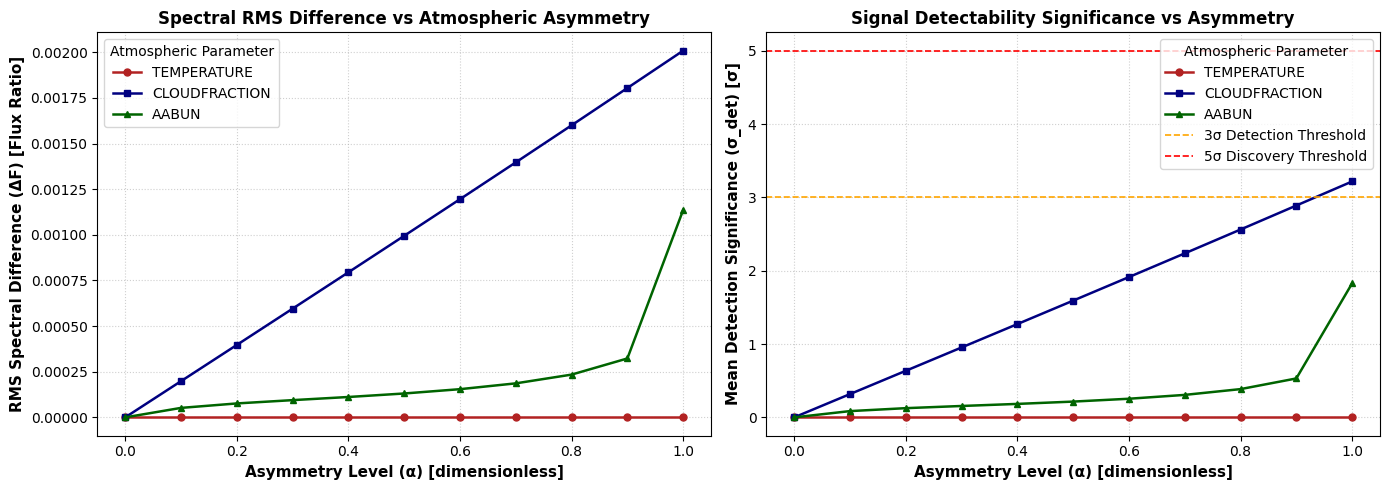

In [ ]:
# PARAMETER COMPARISON (RMS DIFFERENCE & DETECTION SIGNIFICANCE OVER ASYMMETRY α)
fig, axes = plt.subplots(1, 2,
                          figsize=(14, 5))
colors = {'TEMPERATURE': 'firebrick', 'CLOUDFRACTION': 'navy', 'AABUN': 'darkgreen'}
markers = {'TEMPERATURE': 'o', 'CLOUDFRACTION': 's', 'AABUN': '^'}
ax1 = axes[0]
for param in PARAMS:
    sub_df = df_summary[df_summary['Parameter'] == param].sort_values('α')
    ax1.plot(sub_df['α'], sub_df['RMS [Flux Ratio]'], label=param, color=colors[param],
             marker=markers[param], linewidth=1.8, markersize=5)
ax1.set_xlabel("Asymmetry Level (α) [dimensionless]", fontsize=11, fontweight='bold')
ax1.set_ylabel("RMS Spectral Difference (ΔF) [Flux Ratio]", fontsize=11, fontweight='bold')
ax1.set_title("Spectral RMS Difference vs Atmospheric Asymmetry", fontsize=12, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(title="Atmospheric Parameter")
ax2 = axes[1]
for param in PARAMS:
    sub_df = df_summary[df_summary['Parameter'] == param].sort_values('α')
    ax2.plot(sub_df['α'], sub_df['Mean σ_det'], label=param, color=colors[param],
             marker=markers[param], linewidth=1.8, markersize=5)
ax2.axhline(3.0, color='orange', linestyle='--', linewidth=1.2, label='3σ Detection Threshold')
ax2.axhline(5.0, color='red', linestyle='--', linewidth=1.2, label='5σ Discovery Threshold')
ax2.set_xlabel("Asymmetry Level (α) [dimensionless]", fontsize=11, fontweight='bold')
ax2.set_ylabel("Mean Detection Significance (σ_det) [σ]", fontsize=11, fontweight='bold')
ax2.set_title("Signal Detectability Significance vs Asymmetry",
               fontsize=12, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(title="Atmospheric Parameter")
plt.tight_layout()
plt.show()

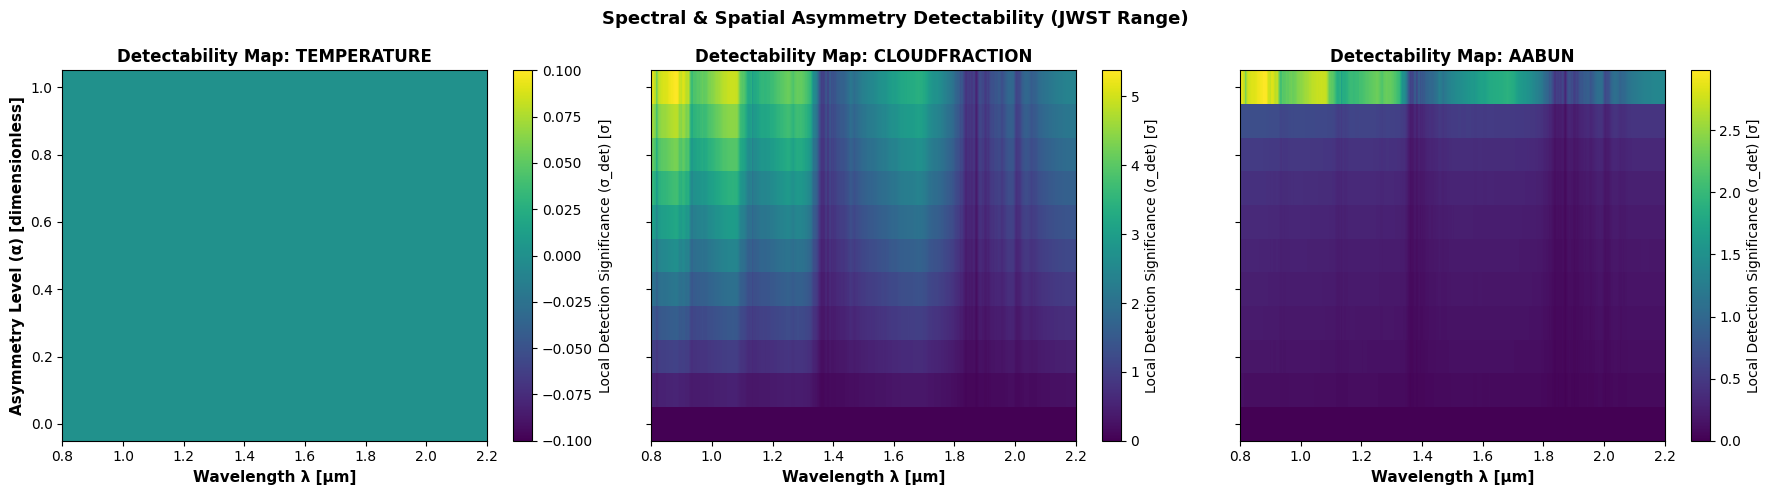

In [ ]:
# SPECTRAL DETECTABILITY HEATMAPS (λ vs ASYMMETRY LEVEL α FOR EACH PARAMETER)
fig, axes = plt.subplots(1, 3, figsize=(18, 5),
                          sharey=True)
for i, param in enumerate(PARAMS):
    ax = axes[i]
    param_df = df_summary[df_summary['Parameter'] == param].sort_values('α')
    heatmap_matrix = []
    asym_levels = param_df['α'].values
    for _, row in param_df.iterrows():
        folder = row['Folder']
        full_path = os.path.join(WORK_DIR, "output_results", folder)
        i_data, _, e_data = load_phase_data(full_path)
        λ_grid = i_data[:, 0]
        σ_comb = np.sqrt(i_data[:, 2]**2 + e_data[:, 2]**2)
        diff_snr = np.abs(i_data[:, -1] - e_data[:, -1]) / σ_comb
        heatmap_matrix.append(diff_snr)
    heatmap_matrix = np.array(heatmap_matrix)
    c = ax.pcolormesh(λ_grid, asym_levels, heatmap_matrix, cmap='viridis', shading='auto')
    cb = fig.colorbar(c, ax=ax)
    cb.set_label("Local Detection Significance (σ_det) [σ]",
                  fontsize=10)
    ax.set_title(f"Detectability Map: {param}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Wavelength λ [μm]", fontsize=11, fontweight='bold')
    if i == 0:
        ax.set_ylabel("Asymmetry Level (α) [dimensionless]", fontsize=11, fontweight='bold')
plt.suptitle("Spectral & Spatial Asymmetry Detectability (JWST Range)",
              fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
# AUTOMATED CFG PARAMETER EXTRACTION AND METADATA EXPORT TO CSV
ASYS_PARAMS = ["ATMOSPHERE-CLOUDFRACTION", "ATMOSPHERE-AABUN",
            "ATMOSPHERE-ASIZE", "ATMOSPHERE-TEMPERATURE"]
extracted_rows = []
for folder_item in TARGET_FOLDERS:
    full_folder_path = os.path.join(WORK_DIR, "output_results", folder_item)
    if not os.path.exists(full_folder_path):
        continue
    for current_phase in ["ingress", "mid", "egress"]:
        target_cfg_path = os.path.join(full_folder_path, f"{current_phase}.cfg")
        if not os.path.exists(target_cfg_path):
            continue
        param_values = {"Folder": folder_item, "Phase": current_phase}
        with open(target_cfg_path, "r", encoding="utf-8") as file_handle:
            cfg_lines = file_handle.readlines()
        for param_key in ASYS_PARAMS:
            for cfg_line in cfg_lines:
                if f"<{param_key}>" in cfg_line:
                    param_values[param_key] = cfg_line.split(">")[1].strip()
        extracted_rows.append(param_values)
df_cfg = pd.DataFrame(extracted_rows)
print(f"Extracted {len(df_cfg)} phase configurations successfully!")
display(df_cfg.head(99))
df_cfg.to_csv("wasp17b_asymmetry_parameters.csv", index=False)

Extracted 99 phase configurations successfully!


,Folder,Phase,ATMOSPHERE-CLOUDFRACTION,ATMOSPHERE-AABUN,ATMOSPHERE-ASIZE,ATMOSPHERE-TEMPERATURE
0,Param_TEMPERATURE_Asym_0.0,ingress,0.5,0.08,1.0,1724.18
1,Param_TEMPERATURE_Asym_0.0,mid,0.5,0.08,1.0,1724.18
2,Param_TEMPERATURE_Asym_0.0,egress,0.5,0.08,1.0,1724.18
3,Param_TEMPERATURE_Asym_0.1,ingress,0.5,0.08,1.0,1696.7620000000002
4,Param_TEMPERATURE_Asym_0.1,mid,0.5,0.08,1.0,1724.18
...,...,...,...,...,...,...
94,Param_AABUN_Asym_0.9,mid,0.5,0.08,1.0,1724.18
95,Param_AABUN_Asym_0.9,egress,0.5,0.007999999999999993,1.0,1724.18
96,Param_AABUN_Asym_1.0,ingress,0.5,1.0,1.0,1724.18
97,Param_AABUN_Asym_1.0,mid,0.5,0.08,1.0,1724.18


### Note on noise model

Noise values (σ) in column 3 of the PSG-generated `.txt` files correspond to the total simulated observational uncertainty provided by PSG. These uncertainties include instrumental and detector contributions together with photon/statistical noise components from the adopted observing configuration.

The resulting σ values are wavelength-dependent and are not strictly constant across the spectrum. In this work, they are used directly as provided by PSG, without introducing additional wavelength-dependent re-scaling or empirical JWST systematics corrections.

The adopted PSG noise model should therefore be interpreted as an idealized simulation-level approximation of JWST transit spectroscopy uncertainties, rather than a complete end-to-end detector systematics treatment.


## Interpretation: Wavelength dependence of asymmetry detectability

The optical region (0.8–1.0 μm) shows the highest σ_det values in the present PSG simulations, while the H₂O-dominated region (1.3–1.5 μm) shows lower detection significance. This indicates that, for the adopted model configuration, the imposed terminator asymmetry produces a stronger differential signal in the optical part of the spectrum.

**Rayleigh scattering and continuum contribution:** One possible explanation is the stronger contribution of short-wavelength scattering and continuum opacity. Rayleigh scattering has a strong wavelength dependence, so changes in the atmospheric properties affecting the continuum can produce a more pronounced spectral difference at shorter wavelengths.

**H₂O absorption region:** The lower σ_det values in the 1.3–1.5 μm region indicate that the particular asymmetry implemented in these simulations produces a smaller ingress-egress difference within this molecular absorption band. This does not imply that H₂O is intrinsically insensitive to terminator asymmetry, since the result depends on the adopted atmospheric structure, abundance and other PSG parameters.

**Interpretation of the regional comparison:** The observed difference between spectral regions should therefore be interpreted as a property of the present simulation setup rather than as a general prediction for all WASP-17b atmospheric models. The comparison is also affected by the number of wavelength bins, spectral resolution and the wavelength-dependent uncertainties provided by PSG.

Further simulations with independently controlled temperature, cloud fraction and atmospheric abundance are required to determine which of these parameters contributes most strongly to the wavelength-dependent asymmetry signal.

The following section summarizes the atmospheric parameters varied in this analysis.

# References and notebook-specific contributions

This analysis combines established transmission spectroscopy methods with a phase-resolved asymmetry study tailored for the WASP-17b model set.

## WASP-17b literature and directly related studies

- _[JWST-TST DREAMS: A Precise Water Abundance for Hot Jupiter WASP-17b from the NIRISS SOSS Transmission Spectrum — Lin et al. (2024)](https://iopscience.iop.org/article/10.3847/1538-3881/ad9688/pdf)_ -This study provides the main literature reference for the WASP-17b transmission-spectrum comparisons used in this analysis. The spectra generated in this notebook are expressed as Fp/F★ (radiance ratio relative to the parent star), rather than as transit depth (Rp/Rs)², ppm or percentage.

- _[A Comprehensive Analysis of WASP-17b's Transmission Spectrum from Space-Based Observations — Alderson et al. (2022)](https://arxiv.org/pdf/2203.02434)_ – comprehensive HST + Spitzer transmission-spectrum analysis of WASP-17b, including atmospheric retrievals, H2O and CO2 detections, cloud interpretation, and JWST relevance.

- _[JWST-TST DREAMS: Quartz Clouds in the Atmosphere of WASP-17b — Grant et al. (2023)](https://arxiv.org/pdf/2310.08637)_ – JWST/MIRI transmission spectroscopy of WASP-17b with quartz-cloud interpretation and aerosol analysis directly relevant to cloud asymmetry studies.

- _[The atmosphere of WASP-17b: Optical high-resolution transmission spectroscopy — Khalafinejad et al. (2018)](https://arxiv.org/pdf/1807.10621)_ – optical transmission spectroscopy of WASP-17b and sodium detection analysis using high-resolution spectra.



## Terminator asymmetry and phase-dependent atmosphere studies

- _[Transmission strings: a technique for spatially mapping exoplanet atmospheres around their terminators — Grant & Wakeford (2023)](https://academic.oup.com/mnras/article/519/4/5114/6889522)_ – spatially resolved transmission-spectroscopy framework and terminator asymmetry methodology.

- _[Spatially resolving the terminator: variation of Fe, temperature, and winds in WASP-76 b across planetary limbs and orbital phase — Gandhi et al. (2022)](https://academic.oup.com/mnras/article-lookup/doi/10.1093/mnras/stac1744)_ – ingress/egress-resolved atmospheric asymmetry analysis and limb-dependent atmospheric structure.

- _[Inhomogeneous terminators on the exoplanet WASP-39 b — Espinoza et al. (2024)](https://doi.org/10.1038/s41586-024-07768-4)_ – JWST observational evidence for non-uniform terminator structure and asymmetric atmospheric properties.

## Statistical and spectral-analysis methodology

- _[A continuum from clear to cloudy hot-Jupiter exoplanets without primordial water depletion - Sing et al. (2016)](https://sci-hub.box/10.1038/nature16068)_ – comparative hot-Jupiter transmission spectra, cloud classification, and wavelength-region interpretation.

- _[A PRECISE WATER ABUNDANCE MEASUREMENT FOR THE HOT JUPITER WASP-43b - Kreidberg et al. (2014)](https://sci-hub.box/10.1038/nature12988)_ – HST/WFC3 water-band detection and cloud-opacity constraints in transmission spectroscopy.

- _[SPITZER TRANSITS OF THE SUPER-EARTH GJ1214B AND IMPLICATIONS FOR ITS ATMOSPHERE - Benneke & Seager et al. (2013)](https://arxiv.org/pdf/1301.6763)_ – atmospheric retrieval statistics, degeneracies, and significance interpretation in exoplanet spectroscopy.

- _[HOW TO DISTINGUISH BETWEEN CLOUDY MINI-NEPTUNES AND WATER/VOLATILE-DOMINATED SUPER-EARTHS - Benneke & Seager (2013)](https://iopscience.iop.org/article/10.1088/0004-637X/778/2/153/pdf)_ – Bayesian atmospheric retrieval and spectral-detection methodology.

## Non-linear and heterogeneous atmospheric effects

- _[Out on a Limb: The Signatures of East-West Asymmetries in Transmission Spectra from General Circulation Models - Arnold et al. (2025)](https://arxiv.org/pdf/2504.14060)_ – discussion of complex atmospheric structure, multidimensional retrieval behaviour, and non-linear spectral responses in heterogeneous atmospheres.

- _[TRIDENT: A Rapid 3D Radiative Transfer Model for Exoplanet Transmission Spectra - MacDonald & Lewis (2021)](https://arxiv.org/pdf/2111.05862)_ – modelling framework for spatially varying atmospheric properties and asymmetric transmission spectra.

- _[Effects of a fully 3D atmospheric structure on exoplanet transmission spectra: retrieval biases due to day-night temperature gradients - Caldas et al. (2019)](https://arxiv.org/pdf/1901.09932)_ – analysis of how heterogeneous terminator structure and opacity variations affect observed transmission spectra.
## Relation to this notebook

The red dashed spectral boundaries correspond to physically motivated wavelength regions commonly used in hot-Jupiter transmission spectroscopy:
- optical / Rayleigh + H− slope region,
- continuum baseline,
- weak H2O transition region,
- strong H2O band,
- H2O wing / opacity plateau,
- second H2O band,
- deep IR tail.

The ingress / mid-transit / egress comparison follows the general approach of spatially resolved and phase-dependent transmission spectroscopy studies. The mid-transit spectrum is retained as a reference phase, while the primary asymmetry test compares ingress and egress spectra.


Regional detection estimates ($σ_{det}$), SNR diagnostics, Monte Carlo realizations, and regional correlation analysis were adapted for this notebook in order to compare different levels of asymmetry configurations consistently within a unified JWST-like simulation framework.

Notebook-specific contributions include:
- Monte Carlo evaluation of regional $σ_{det}$ values using noisy PSG realizations;
- consolidated ingress / mid / egress comparative diagnostics;
- physically motivated wavelength-region segmentation applied uniformly across asymmetry regimes;
- region-by-region asymmetry tracking using RMS, correlation ($ρ$), detectability, and spectral-difference metrics.